In [1]:
import sys
from pathlib import Path

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage
from rich import print

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from tqdm.notebook import tqdm

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
STATIONS_PCR

{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.3},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Uch-Kurgan': {'lat': 41.12, 'lon': 72.1},
 'Garm': {'lat': 39.05, 'lon': 70.33}}

In [3]:
pcr_glob_directory = PCR_GLOBAL_PARAMS  # GlobalOption uit .ini
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL


parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_container_prefactor.ini",
    target_model="pcrglobwb",
    supported_model_versions={"16mar"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [4]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_16mar.sif")
my_image.version

'16mar'

In [5]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

no_extraction = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/ini_files/test_container_prefactor.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'16mar'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1940-01-01T00:00:00Z',
        end_time='1960-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
    )
)

In [6]:
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "1950-04-10T00:00:00Z"

In [7]:
reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)
reference_config, reference_dir

no_extraction_config, no_extraction_dir = no_extraction.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)


In [8]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-04-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 99

In [9]:
reference.initialize(reference_config)
no_extraction.initialize(no_extraction_config)

## channel selection

Using latest discovered discharge file: 
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_r
uns/pcr-globwb/calibration_run_prefactor_test_overnight/run_1a3b24cf/netcdf/discharge_dailyTot_output.nc

Cells above 100.0: 572

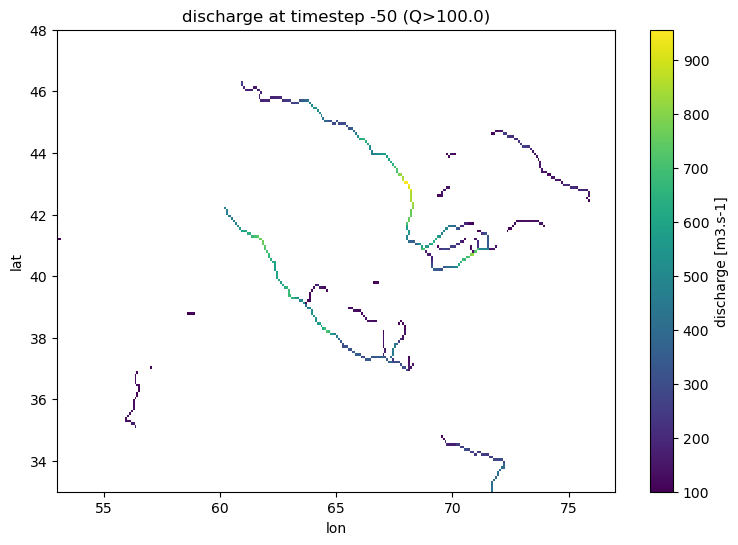

In [10]:
import xarray as xr
from pathlib import Path

output_root = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb"
)

# Prefer a user-pinned file; otherwise auto-discover the newest discharge output file.
test_file = output_root / "calibration_run_prefactor_test_24mar_night/run_7ab23e06/netcdf/discharge_dailyTot_output.nc"
if not test_file.exists():
    candidates = sorted(output_root.glob("**/netcdf/discharge_dailyTot_output.nc"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(
            f"No discharge_dailyTot_output.nc found under {output_root}. "
            "Check your run output location or update output_root/test_file."
        )
    test_file = candidates[-1]
    print(f"Using latest discovered discharge file: {test_file}")
else:
    print(f"Using pinned discharge file: {test_file}")

data = xr.open_dataset(test_file)

chosen_timestep = -50
time_step = -50
cut_off_value = 100.0

# Pick the discharge-like variable if present; otherwise use the first variable.
var_name = next((v for v in data.data_vars if "discharge" in v.lower()), list(data.data_vars)[0])
da = data[var_name]

# Use the time dimension if available, otherwise the first dimension.
time_dim = "time" if "time" in da.dims else da.dims[0]
slice_t = da.isel({time_dim: time_step})

values = slice_t.values.ravel()
values = values[~np.isnan(values)]

slice_chosen = da.isel({time_dim: chosen_timestep})
above_cutoff = slice_chosen.where(slice_chosen > cut_off_value)

n_above = int((slice_chosen > cut_off_value).sum().item())
print(f"Cells above {cut_off_value}: {n_above}")

plt.figure(figsize=(9, 6))
above_cutoff.plot(cmap="viridis", vmin=cut_off_value)
plt.title(f"{var_name} at timestep {chosen_timestep} (Q>{cut_off_value})")
plt.xlabel("lon")
plt.ylabel("lat")
plt.show()

In [11]:
# Build a list/table of coordinates where value > cut_off_value.
coords_df = above_cutoff.to_series().dropna().reset_index(name=var_name)
coords_df = coords_df.sort_values(by=var_name, ascending=True).reset_index(drop=True)

print(f"Number of coordinates above cutoff: {len(coords_df)}")
coords_df.tail(20)

Number of coordinates above cutoff: 572

,lat,lon,discharge
552,41.125000,61.875000,759.760254
553,41.208332,61.791668,760.764282
554,43.291668,67.708336,772.195923
555,40.708332,70.791664,791.976501
556,42.208332,68.291664,806.912781
557,40.708332,70.875000,817.098816
558,42.291668,68.291664,817.225098
559,43.291668,67.791664,830.443970
560,43.208332,67.875000,831.932678
561,42.375000,68.291664,834.432983


In [12]:
mask_drop = (
    ((coords_df["lon"] > 69) & (coords_df["lat"] < 36))
    | ((coords_df["lon"] > 70) & (coords_df["lat"] < 38))
    | ((coords_df["lon"] < 60))
    | ((coords_df["lon"] > 74.01))
)
rows_dropped = int(mask_drop.sum())

coords_df = coords_df.loc[~mask_drop].reset_index(drop=True)

print(f"Dropped rows: {rows_dropped}")
print(f"Remaining rows: {len(coords_df)}")
coords_df.head(20)

Dropped rows: 104

Remaining rows: 468

,lat,lon,discharge
0,41.458332,72.375000,100.141235
1,41.708332,70.875000,101.619720
2,39.791668,66.625000,103.576538
3,41.541668,72.458336,106.394386
4,44.625000,71.708336,106.587059
5,43.958332,69.791664,107.473289
6,38.791668,66.125000,107.671387
7,41.458332,71.125000,108.908730
8,43.958332,70.125000,109.752419
9,38.208332,67.041664,109.979942


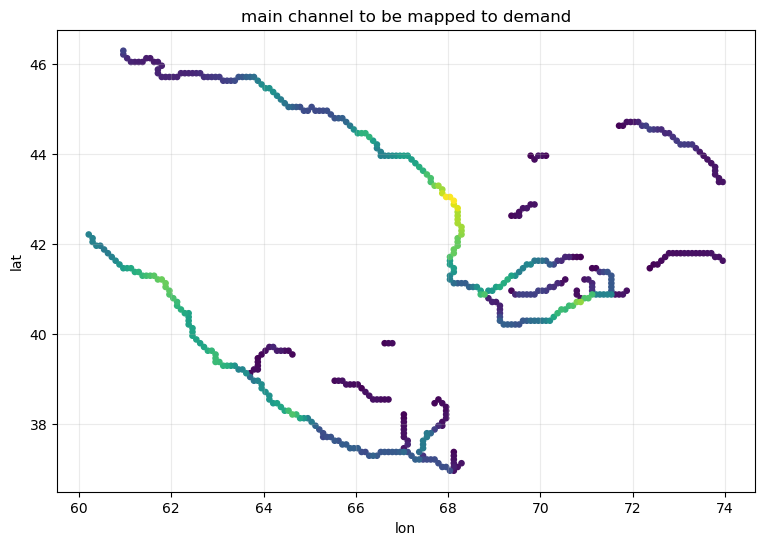

In [13]:
plt.figure(figsize=(9, 6))
plt.scatter(
    coords_df["lon"],
    coords_df["lat"],
    c=coords_df[var_name],
    s=14,
    cmap="viridis",
)
#plt.colorbar(label=f"{var_name} ({da.attrs.get('units', 'unknown units')})")
#plt.title(f"Discharge > {cut_off_value} at timestep {chosen_timestep}: {len(coords_df)} points")
plt.title("main channel to be mapped to demand")
plt.xlabel("lon")
plt.ylabel("lat")
plt.grid(alpha=0.25)
plt.show()

In [14]:
# Demand variable selection helper used by mapping/allocation cells
preferred_demand_vars = [
    "evaporation_from_irrigation_volume",
    "irrigation_demand",
]


def _get_first_available_demand_da(model, preferred_names):
    last_error = None

    for name in preferred_names:
        try:
            da_try = model.get_value_as_xarray(name)
            if float(np.nanmax(da_try.values)) > 0:
                return name, da_try
        except Exception as exc:
            last_error = exc

    bmi = getattr(model, "_bmi", None)
    if bmi is not None:
        available_names = []
        for attr_name in ("get_output_var_names", "get_input_var_names", "get_var_names"):
            if hasattr(bmi, attr_name):
                try:
                    available_names.extend(list(getattr(bmi, attr_name)()))
                except Exception:
                    pass

        for name in sorted(set(available_names)):
            lowered = name.lower()
            if any(keyword in lowered for keyword in ("demand", "irrig", "abstraction")):
                try:
                    da_try = model.get_value_as_xarray(name)
                    if float(np.nanmax(da_try.values)) > 0:
                        return name, da_try
                except Exception as exc:
                    last_error = exc

    raise RuntimeError(
        "Could not find a readable non-zero irrigation-demand variable. "
        f"Tried preferred names: {preferred_names}"
    ) from last_error

In [15]:
# Build nearest-channel mapping and allocation helper using the filtered channel-cell list (coords_df).
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm


def _find_lat_lon_columns(df: pd.DataFrame):
    lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
    lon_col = next((c for c in df.columns if "lon" in c.lower()), None)
    if lat_col is None or lon_col is None:
        raise ValueError("Could not detect latitude/longitude columns.")
    return lat_col, lon_col


def _find_spatial_dims(da: xr.DataArray):
    dims = list(da.dims)
    if len(dims) < 2:
        raise ValueError(f"Expected at least 2 dims, got {dims}")

    lat_dim = next((d for d in dims if "lat" in d.lower() or d.lower() in ("y", "rlat")), None)
    lon_dim = next((d for d in dims if "lon" in d.lower() or d.lower() in ("x", "rlon")), None)

    if lat_dim is not None and lon_dim is not None and lat_dim != lon_dim:
        return lat_dim, lon_dim

    non_time = [d for d in dims if "time" not in d.lower()]
    if len(non_time) >= 2:
        return non_time[0], non_time[1]

    return dims[0], dims[1]


def _coord_values(da: xr.DataArray, dim_name: str) -> np.ndarray:
    if dim_name in da.coords:
        return np.asarray(da[dim_name].values, dtype=float)
    return np.arange(da.sizes[dim_name], dtype=float)


def _grid_index_table(da: xr.DataArray):
    lat_dim, lon_dim = _find_spatial_dims(da)
    lat_values = _coord_values(da, lat_dim)
    lon_values = _coord_values(da, lon_dim)

    lat_idx, lon_idx = np.meshgrid(
        np.arange(len(lat_values), dtype=np.int64),
        np.arange(len(lon_values), dtype=np.int64),
        indexing="ij",
    )
    lat_grid, lon_grid = np.meshgrid(lat_values, lon_values, indexing="ij")

    grid_df = pd.DataFrame(
        {
            "lat": lat_grid.reshape(-1),
            "lon": lon_grid.reshape(-1),
            "lat_idx": lat_idx.reshape(-1),
            "lon_idx": lon_idx.reshape(-1),
        }
    )
    return grid_df, lat_dim, lon_dim, lat_values, lon_values


def _to_latlon_df(da: xr.DataArray, value_name: str):
    df = da.to_series().reset_index(name=value_name)
    lat_col, lon_col = _find_lat_lon_columns(df)
    return df.rename(columns={lat_col: "lat", lon_col: "lon"})


def _coord_to_index(coord_values: np.ndarray, coord: float) -> int:
    return int(np.abs(np.asarray(coord_values, dtype=float) - float(coord)).argmin())


def _nearest_source_ids(demand_xy: np.ndarray, source_xy: np.ndarray, chunk_size: int = 4000):
    # Fallback that does not require scipy; computes nearest source per demand chunk.
    out = np.empty(demand_xy.shape[0], dtype=np.int64)
    for start in range(0, demand_xy.shape[0], chunk_size):
        stop = min(start + chunk_size, demand_xy.shape[0])
        block = demand_xy[start:stop]
        diff = block[:, None, :] - source_xy[None, :, :]
        dist2 = np.sum(diff * diff, axis=2)
        out[start:stop] = np.argmin(dist2, axis=1)
    return out


def _build_source_index_table(template_da: xr.DataArray, channel_cells_df: pd.DataFrame):
    _, lat_dim, lon_dim, lat_values, lon_values = _grid_index_table(template_da)

    source_df = channel_cells_df[["lat", "lon"]].drop_duplicates().reset_index(drop=True).copy()
    source_df = source_df.rename(columns={"lat": "raw_lat", "lon": "raw_lon"})
    source_df["source_id"] = np.arange(len(source_df), dtype=np.int64)
    source_df["source_lat_idx"] = source_df["raw_lat"].map(lambda value: _coord_to_index(lat_values, value)).astype(np.int64)
    source_df["source_lon_idx"] = source_df["raw_lon"].map(lambda value: _coord_to_index(lon_values, value)).astype(np.int64)
    source_df["source_flat_idx"] = (source_df["source_lat_idx"] * len(lon_values) + source_df["source_lon_idx"]).astype(np.int64)

    # Coordinates snapped to template grid (safe when raw lat/lon originates from another grid/projection).
    source_df["source_lat"] = lat_values[source_df["source_lat_idx"].to_numpy(dtype=np.int64)]
    source_df["source_lon"] = lon_values[source_df["source_lon_idx"].to_numpy(dtype=np.int64)]

    return source_df, lat_dim, lon_dim


def _ranges_overlap(a_min, a_max, b_min, b_max) -> bool:
    return not (a_max < b_min or b_max < a_min)


def build_demand_to_channel_map(demand_da: xr.DataArray, template_da: xr.DataArray, channel_cells_df: pd.DataFrame):
    demand_grid_df, _, _, _, _ = _grid_index_table(demand_da)
    source_df, lat_dim, lon_dim = _build_source_index_table(template_da, channel_cells_df)

    # Prefer lat/lon matching when ranges overlap; otherwise use index-space matching.
    lat_overlap = _ranges_overlap(
        float(demand_grid_df["lat"].min()),
        float(demand_grid_df["lat"].max()),
        float(source_df["source_lat"].min()),
        float(source_df["source_lat"].max()),
    )
    lon_overlap = _ranges_overlap(
        float(demand_grid_df["lon"].min()),
        float(demand_grid_df["lon"].max()),
        float(source_df["source_lon"].min()),
        float(source_df["source_lon"].max()),
    )
    use_latlon = bool(lat_overlap and lon_overlap)

    if use_latlon:
        demand_xy = demand_grid_df[["lat", "lon"]].to_numpy(dtype=float)
        source_xy = source_df[["source_lat", "source_lon"]].to_numpy(dtype=float)
        match_mode = "latlon"
    else:
        demand_xy = demand_grid_df[["lat_idx", "lon_idx"]].to_numpy(dtype=float)
        source_xy = source_df[["source_lat_idx", "source_lon_idx"]].to_numpy(dtype=float)
        match_mode = "index"

    try:
        from scipy.spatial import cKDTree  # type: ignore
        tree = cKDTree(source_xy)
        _, nearest_ids = tree.query(demand_xy, k=1)
    except Exception:
        nearest_ids = _nearest_source_ids(demand_xy, source_xy, chunk_size=4000)

    mapping_df = demand_grid_df.copy()
    mapping_df["source_id"] = nearest_ids.astype(np.int64)
    mapping_df = mapping_df.merge(
        source_df[[
            "source_id",
            "source_lat_idx",
            "source_lon_idx",
            "source_flat_idx",
            "source_lat",
            "source_lon",
            "raw_lat",
            "raw_lon",
        ]],
        on="source_id",
        how="left",
    )
    mapping_df["match_mode"] = match_mode

    return mapping_df, source_df, lat_dim, lon_dim


def allocate_irrigation_to_channel_storage(
    demand_da: xr.DataArray,
    storage_da: xr.DataArray,
    mapping_df: pd.DataFrame,
    source_df: pd.DataFrame,
    demand_scale: float = 1.0,
    max_demand_points: int | None = None,
    random_state: int = 42,
):
    demand_df = _to_latlon_df(demand_da, "demand")
    demand_df = demand_df[demand_df["demand"] > 0].copy()
    if demand_scale != 1.0:
        demand_df["demand"] = demand_df["demand"] * float(demand_scale)

    if max_demand_points is not None and len(demand_df) > max_demand_points:
        demand_df = demand_df.sample(n=max_demand_points, random_state=random_state).reset_index(drop=True)

    # Primary match in index-space derived from mapping grid axes.
    map_lat_axis = np.sort(mapping_df["lat"].dropna().unique().astype(float))
    map_lon_axis = np.sort(mapping_df["lon"].dropna().unique().astype(float))
    demand_df["lat_idx"] = demand_df["lat"].map(lambda value: _coord_to_index(map_lat_axis, value)).astype(np.int64)
    demand_df["lon_idx"] = demand_df["lon"].map(lambda value: _coord_to_index(map_lon_axis, value)).astype(np.int64)

    map_idx = mapping_df[["lat_idx", "lon_idx", "source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]].drop_duplicates()
    demand_df = demand_df.merge(map_idx, on=["lat_idx", "lon_idx"], how="left")

    # Fallback for any unmatched rows: nearest-neighbor in lat/lon to mapping rows.
    missing_mask = demand_df["source_id"].isna()
    if bool(missing_mask.any()):
        demand_xy = demand_df.loc[missing_mask, ["lat", "lon"]].to_numpy(dtype=float)
        mapping_xy = mapping_df[["lat", "lon"]].to_numpy(dtype=float)
        try:
            from scipy.spatial import cKDTree  # type: ignore
            tree = cKDTree(mapping_xy)
            _, nearest_indices = tree.query(demand_xy, k=1)
        except Exception:
            nearest_indices = _nearest_source_ids(demand_xy, mapping_xy, chunk_size=4000)
        matched_mapping = mapping_df.iloc[nearest_indices][["source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]].reset_index(drop=True)
        demand_df.loc[missing_mask, ["source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]] = matched_mapping.values

    demand_df[["source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]] = demand_df[[
        "source_id",
        "source_flat_idx",
        "source_lat_idx",
        "source_lon_idx",
    ]].astype(np.int64)

    storage_flat = np.asarray(storage_da.values, dtype=float).reshape(-1).copy()
    source_flat_indices = source_df["source_flat_idx"].to_numpy(dtype=np.int64)
    source_remaining = storage_flat[source_flat_indices].copy()

    alloc_rows = []
    unmet_rows = []

    for d_idx, row in demand_df.iterrows():
        sid = int(row["source_id"])
        flat_idx = int(row["source_flat_idx"])
        needed = float(row["demand"])
        available = float(source_remaining[sid])
        extracted = min(needed, max(0.0, available))
        source_remaining[sid] = available - extracted
        storage_flat[flat_idx] = source_remaining[sid]
        unmet = needed - extracted

        alloc_rows.append(
            {
                "demand_id": int(d_idx),
                "demand_lat": float(row["lat"]),
                "demand_lon": float(row["lon"]),
                "source_id": sid,
                "source_flat_idx": flat_idx,
                "source_lat_idx": int(row["source_lat_idx"]),
                "source_lon_idx": int(row["source_lon_idx"]),
                "demand": needed,
                "extracted": extracted,
                "unmet": unmet,
            }
        )
        if unmet > 0:
            unmet_rows.append({"demand_id": int(d_idx), "unmet": unmet})

    allocation_df = pd.DataFrame(alloc_rows)
    unmet_df = pd.DataFrame(unmet_rows)

    updated_storage = storage_da.copy()
    updated_storage.values = storage_flat.reshape(storage_da.shape)

    return updated_storage, allocation_df, unmet_df


# Build one-time mapping table. Prefer model demand grid; fallback to external netcdf grid.
channel_cells_df = coords_df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)

try:
    demand_template_var, demand_template_da = _get_first_available_demand_da(reference, preferred_demand_vars)
    print(f"Using model demand grid as mapping template: {demand_template_var}")
except Exception as exc:
    demand_template_var = "external_discharge_template"
    demand_template_da = da.isel({time_dim: 0}) if time_dim in da.dims else da
    print(f"Falling back to external template grid because model demand read failed: {exc}")

demand_to_channel_map_df, channel_source_df, grid_lat_dim, grid_lon_dim = build_demand_to_channel_map(
    demand_template_da,
    demand_template_da,
    channel_cells_df,
)

unique_source_ids = int(demand_to_channel_map_df["source_id"].nunique())
unique_source_flat = int(channel_source_df["source_flat_idx"].nunique())
if unique_source_flat <= 1 or unique_source_ids <= 1:
    template_lat_min = float(demand_to_channel_map_df["lat"].min())
    template_lat_max = float(demand_to_channel_map_df["lat"].max())
    template_lon_min = float(demand_to_channel_map_df["lon"].min())
    template_lon_max = float(demand_to_channel_map_df["lon"].max())
    raw_lat_min = float(channel_source_df["raw_lat"].min())
    raw_lat_max = float(channel_source_df["raw_lat"].max())
    raw_lon_min = float(channel_source_df["raw_lon"].min())
    raw_lon_max = float(channel_source_df["raw_lon"].max())
    raise RuntimeError(
        "Channel mapping collapsed to <=1 unique source location. "
        "This usually means channel coordinates are from a different grid/region than the demand template. "
        f"Template lat/lon range=({template_lat_min:.3f},{template_lat_max:.3f})/({template_lon_min:.3f},{template_lon_max:.3f}); "
        f"Channel raw lat/lon range=({raw_lat_min:.3f},{raw_lat_max:.3f})/({raw_lon_min:.3f},{raw_lon_max:.3f}). "
        "Regenerate channel_cells_df from the same model grid as demand/channel_storage before mapping."
    )

print(f"Channel source cells: {len(channel_source_df)}")
print(f"Template grid cells mapped: {len(demand_to_channel_map_df)}")
print(f"Mapping mode: {demand_to_channel_map_df['match_mode'].iloc[0]}")
print(f"Unique mapped source IDs: {unique_source_ids}")
print(f"Unique source flat indices: {unique_source_flat} / {len(channel_source_df)}")
print(f"Mapping lat range: {demand_to_channel_map_df['lat'].min():.6f} - {demand_to_channel_map_df['lat'].max():.6f}")
print(f"Mapping lon range: {demand_to_channel_map_df['lon'].min():.6f} - {demand_to_channel_map_df['lon'].max():.6f}")
demand_to_channel_map_df.head()

Falling back to external template grid because model demand read failed: Could not find a readable non-zero 
irrigation-demand variable. Tried preferred names: ['evaporation_from_irrigation_volume', 'irrigation_demand']

Channel source cells: 468

Template grid cells mapped: 51840

Mapping mode: latlon

Unique mapped source IDs: 468

Unique source flat indices: 468 / 468

Mapping lat range: 33.041668 - 47.958332

Mapping lon range: 53.041668 - 76.958336

,lat,lon,lat_idx,lon_idx,source_id,source_lat_idx,source_lon_idx,source_flat_idx,source_lat,source_lon,raw_lat,raw_lon,match_mode
0,47.958332,53.041668,0,0,199,20,95,5855,46.291668,60.958332,46.291668,60.958332,latlon
1,47.958332,53.125000,0,1,199,20,95,5855,46.291668,60.958332,46.291668,60.958332,latlon
2,47.958332,53.208332,0,2,199,20,95,5855,46.291668,60.958332,46.291668,60.958332,latlon
3,47.958332,53.291668,0,3,199,20,95,5855,46.291668,60.958332,46.291668,60.958332,latlon
4,47.958332,53.375000,0,4,199,20,95,5855,46.291668,60.958332,46.291668,60.958332,latlon


In [16]:
# Rebuild channel cells from model grid (same grid as demand/storage) to avoid cross-grid collapse.
def _pick_channel_proxy_da(model):
    candidates = [
        "channel_storage",
        "discharge",
        "discharge_dailyTot",
        "river_discharge",
        "channel_discharge",
    ]
    for name in candidates:
        try:
            da_try = model.get_value_as_xarray(name)
            vals = np.asarray(da_try.values, dtype=float)
            if np.isfinite(vals).any():
                return name, da_try
        except Exception:
            pass

    # Last-resort discovery from BMI names.
    bmi = getattr(model, "_bmi", None)
    if bmi is not None:
        all_names = []
        for attr_name in ("get_output_var_names", "get_input_var_names", "get_var_names"):
            if hasattr(bmi, attr_name):
                try:
                    all_names.extend(list(getattr(bmi, attr_name)()))
                except Exception:
                    pass
        for name in sorted(set(all_names)):
            low = name.lower()
            if any(k in low for k in ("channel", "discharge", "river")):
                try:
                    da_try = model.get_value_as_xarray(name)
                    vals = np.asarray(da_try.values, dtype=float)
                    if np.isfinite(vals).any():
                        return name, da_try
                except Exception:
                    pass

    # Graceful fallback to externally loaded discharge grid if present in notebook state.
    if "da" in globals():
        try:
            da_try = da
            vals = np.asarray(da_try.values, dtype=float)
            if np.isfinite(vals).any():
                return "external_da_fallback", da_try
        except Exception:
            pass

    raise RuntimeError(
        "Could not find a readable channel/discharge proxy on model grid. "
        "Try re-running setup/initialize cells, or ensure variable 'da' is available as fallback."
    )


def _build_main_channel_cells_from_model_grid(proxy_da: xr.DataArray, q: float = 0.90, min_cells: int = 300):
    proxy_df = _to_latlon_df(proxy_da, "proxy")
    proxy_df = proxy_df[np.isfinite(proxy_df["proxy"])].copy()
    proxy_df = proxy_df[proxy_df["proxy"] > 0].copy()
    if proxy_df.empty:
        raise RuntimeError("Channel proxy has no positive finite cells.")

    threshold = float(proxy_df["proxy"].quantile(q))
    channel_df = proxy_df[proxy_df["proxy"] >= threshold][["lat", "lon", "proxy"]].copy()

    # Ensure enough channel points: relax quantile progressively if needed.
    relax_steps = [0.85, 0.80, 0.75, 0.70, 0.65, 0.60]
    for q_try in relax_steps:
        if len(channel_df) >= min_cells:
            break
        thr_try = float(proxy_df["proxy"].quantile(q_try))
        candidate = proxy_df[proxy_df["proxy"] >= thr_try][["lat", "lon", "proxy"]].copy()
        if len(candidate) > len(channel_df):
            channel_df = candidate
            threshold = thr_try

    channel_df = channel_df.sort_values("proxy", ascending=False).drop_duplicates(subset=["lat", "lon"]).reset_index(drop=True)
    return channel_df, threshold


proxy_name, proxy_da = _pick_channel_proxy_da(reference)
channel_cells_model_df, proxy_threshold = _build_main_channel_cells_from_model_grid(
    proxy_da=proxy_da,
    q=0.90,
    min_cells=300,
)

# Always rebuild the demand template from CURRENT model state in this same cell to avoid stale-grid mismatch.
try:
    demand_template_var_current, demand_template_da_current = _get_first_available_demand_da(reference, preferred_demand_vars)
except Exception:
    demand_template_var_current, demand_template_da_current = proxy_name, proxy_da

channel_cells_df = channel_cells_model_df[["lat", "lon"]].copy()
print(f"Using channel proxy: {proxy_name}")
print(f"Using demand template: {demand_template_var_current}")
print(f"Proxy threshold used: {proxy_threshold:.6g}")
print(f"Channel cells from grid: {len(channel_cells_df)}")
print(f"Channel cell lat range: {channel_cells_df['lat'].min():.6f} - {channel_cells_df['lat'].max():.6f}")
print(f"Channel cell lon range: {channel_cells_df['lon'].min():.6f} - {channel_cells_df['lon'].max():.6f}")

# Rebuild mapping with channel cells and current demand template from same runtime state.
demand_to_channel_map_df, channel_source_df, grid_lat_dim, grid_lon_dim = build_demand_to_channel_map(
    demand_template_da_current,
    demand_template_da_current,
    channel_cells_df,
)
print(f"Rebuilt mapping mode: {demand_to_channel_map_df['match_mode'].iloc[0]}")
print(f"Unique mapped source IDs: {demand_to_channel_map_df['source_id'].nunique()}")
print(f"Unique source flat indices: {channel_source_df['source_flat_idx'].nunique()} / {len(channel_source_df)}")
print(f"Mapping lat range: {demand_to_channel_map_df['lat'].min():.6f} - {demand_to_channel_map_df['lat'].max():.6f}")
print(f"Mapping lon range: {demand_to_channel_map_df['lon'].min():.6f} - {demand_to_channel_map_df['lon'].max():.6f}")
demand_to_channel_map_df.head()

Using channel proxy: external_da_fallback

Using demand template: external_da_fallback

Proxy threshold used: 12.0831

Channel cells from grid: 7656

Channel cell lat range: 33.041668 - 46.958332

...

Unique mapped source IDs: 7656

Unique source flat indices: 7656 / 7656

Mapping lat range: 33.041668 - 47.958332

Mapping lon range: 53.041668 - 76.958336

,lat,lon,lat_idx,lon_idx,source_id,source_lat_idx,source_lon_idx,source_flat_idx,source_lat,source_lon,raw_lat,raw_lon,match_mode
0,47.958332,53.041668,0,0,7126,12,0,3456,46.958332,53.041668,46.958332,53.041668,latlon
1,47.958332,53.125000,0,1,6977,12,1,3457,46.958332,53.125000,46.958332,53.125000,latlon
2,47.958332,53.208332,0,2,6977,12,1,3457,46.958332,53.125000,46.958332,53.125000,latlon
3,47.958332,53.291668,0,3,6977,12,1,3457,46.958332,53.125000,46.958332,53.125000,latlon
4,47.958332,53.375000,0,4,6977,12,1,3457,46.958332,53.125000,46.958332,53.125000,latlon


In [17]:
# === DEBUG: Trace allocation function step-by-step ===

try:
    test_demand_var, test_demand_da = _get_first_available_demand_da(reference, preferred_demand_vars)
except Exception as exc:
    print("Demand debug skipped: no readable positive demand field at current model state.")
    print(f"Reason: {exc}")
    print("Tip: rerun setup/initialize and at least one update step before this debug cell.")
else:
    print(f"Demand variable: {test_demand_var}")
    print(f"Demand shape: {test_demand_da.shape}, dtype: {test_demand_da.dtype}")

    test_demand_df = _to_latlon_df(test_demand_da, "demand")
    print(f"\nDemand dataframe shape after to_latlon_df: {test_demand_df.shape}")
    print(f"Demand dataframe columns: {test_demand_df.columns.tolist()}")
    print(f"First 3 rows:\n{test_demand_df.head(3)}")

    test_demand_filtered = test_demand_df[test_demand_df["demand"] > 0].copy()
    print(f"\nAfter filtering demand > 0: {len(test_demand_filtered)} rows")
    if len(test_demand_filtered) == 0:
        print("No positive demand points at current state.")
    else:
        print(f"Demand stats - min: {test_demand_filtered['demand'].min():.6g}, max: {test_demand_filtered['demand'].max():.6g}, mean: {test_demand_filtered['demand'].mean():.6g}")

        # Test the spatial matching
        demand_xy = test_demand_filtered[["lat", "lon"]].to_numpy(dtype=float)
        mapping_xy = demand_to_channel_map_df[["lat", "lon"]].to_numpy(dtype=float)

        print(f"\nDemand XY shape: {demand_xy.shape}")
        print(f"Mapping XY shape: {mapping_xy.shape}")
        print(f"Demand sample xy (first 3): \n{demand_xy[:3]}")
        print(f"Mapping sample xy (first 3): \n{mapping_xy[:3]}")

        # Try the KDTree matching
        try:
            from scipy.spatial import cKDTree
            tree = cKDTree(mapping_xy)
            distances, nearest_indices = tree.query(demand_xy, k=1)
            print(f"\nKDTree matching successful!")
            print(f"Nearest indices shape: {nearest_indices.shape}")
            print(f"Distances stats - min: {distances.min():.6g}, max: {distances.max():.6g}, mean: {distances.mean():.6g}")
            print(f"First 5 matched indices: {nearest_indices[:5]}")
            print(f"First 5 distances: {distances[:5]}")
        except Exception as e:
            print(f"KDTree matching failed: {e}")

Demand debug skipped: no readable positive demand field at current model state.

Reason: Could not find a readable non-zero irrigation-demand variable. Tried preferred names: 
['evaporation_from_irrigation_volume', 'irrigation_demand']

Tip: rerun setup/initialize and at least one update step before this debug cell.

In [18]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
Stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly_ref", "Chatly_no"]
)

Stations_timeseries_before = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly_ref", "Chatly_no"]
)



In [20]:
# Loop similar to test_pcr_images, but now withdrawals are distributed from many demand pixels to mapped channel cells.
irrigation_diagnostics = []

# Optional conversion factor if demand units differ from channel_storage units.
demand_scale = 0.25

Chatly_station_latitude = 42.34332908492399-0.5 # Amu Darya near Chatly
Chatly_station_longitude = 59.627516175820965+0.9 



# Optional cap for faster tests; set None to use full domain each day.
max_demand_points = None

preferred_demand_vars = [
    "irrigation_gross_demand_volume",
    # "irrigationGrossDemandVolume",
    # "surface_water_abstraction_volume",
    # "surfaceWaterAbstractionVolume",
    # "totalGrossDemand",
    #"evaporation_from_irrigation_volume",
    #"irrigation_demand",
]

def summarize_preferred_demand_vars(model, variable_names):
    rows = []
    for name in variable_names:
        try:
            da_try = model.get_value_as_xarray(name)
            values = np.asarray(da_try.values, dtype=float)
            rows.append(
                {
                    "variable": name,
                    "readable": True,
                    "min": float(np.nanmin(values)),
                    "max": float(np.nanmax(values)),
                    "mean": float(np.nanmean(values)),
                    "sum": float(np.nansum(values)),
                    "n_nonzero": int(np.count_nonzero(np.nan_to_num(values, nan=0.0))),
                    "error": "",
                }
            )
        except Exception as exc:
            rows.append(
                {
                    "variable": name,
                    "readable": False,
                    "min": np.nan,
                    "max": np.nan,
                    "mean": np.nan,
                    "sum": np.nan,
                    "n_nonzero": 0,
                    "error": str(exc),
                }
            )
    return pd.DataFrame(rows)

required_helpers = [
    "allocate_irrigation_to_channel_storage",
    "_get_first_available_demand_da",
]
missing_helpers = [name for name in required_helpers if name not in globals()]
if missing_helpers:
    raise RuntimeError(
        "Missing required helper definitions: "
        f"{missing_helpers}. Run the helper-definition cell above, then re-run this cell."
    )

# Stats table for all preferred demand variables at current model state.
preferred_demand_stats_df = summarize_preferred_demand_vars(reference, preferred_demand_vars)
display(preferred_demand_stats_df)

selected_demand_var = None

reference.update()
no_extraction.update()

for step_idx in tqdm(range(number_of_days - 2), desc="Running model with irrigation withdrawals"):
    time_before = reference.time_as_isostr
    discharge_at_Chatly_ref = reference.get_value_at_coords(
        "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    )
    discharge_at_Chatly_no = no_extraction.get_value_at_coords(
        "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    )
    Stations_timeseries_before.loc[time_before, "Chatly_ref"] = discharge_at_Chatly_ref[0]
    Stations_timeseries_before.loc[time_before, "Chatly_no"] = discharge_at_Chatly_no[0]

    # Advance one day first, then apply same-day irrigation demand to channel storage.
    reference.update()
    no_extraction.update()

    selected_demand_var, irrigation_demand_da = _get_first_available_demand_da(reference, preferred_demand_vars)
    channel_storage_da = reference.get_value_as_xarray("channel_storage")

    demand_mean = float(np.nanmean(irrigation_demand_da.values))
    storage_mean_before = float(np.nanmean(channel_storage_da.values))
    demand_positive = int(np.count_nonzero(np.nan_to_num(irrigation_demand_da.values, nan=0.0) > 0))
    storage_positive = int(np.count_nonzero(np.nan_to_num(channel_storage_da.values, nan=0.0) > 0))

    updated_storage_da, allocation_df, unmet_df = allocate_irrigation_to_channel_storage(
        demand_da=irrigation_demand_da,
        storage_da=channel_storage_da,
        mapping_df=demand_to_channel_map_df,
        source_df=channel_source_df,
        demand_scale=demand_scale,
        max_demand_points=max_demand_points,
    )

    reference.set_value("channel_storage", updated_storage_da.values.flatten())

    storage_mean_after = float(np.nanmean(updated_storage_da.values))
    extracted_mean = float(allocation_df["extracted"].mean()) if len(allocation_df) else 0.0
    extracted_total = float(allocation_df["extracted"].sum()) if len(allocation_df) else 0.0
    matched_demands = int(len(allocation_df))

    print(
        f"step={step_idx:03d} | t={reference.time_as_isostr} | var={selected_demand_var} | "
        f"mean_demand={demand_mean:.6g} | mean_storage_before={storage_mean_before:.6g} | "
        f"mean_storage_after={storage_mean_after:.6g} | mean_extracted={extracted_mean:.6g} | "
        f"matched={matched_demands} | extracted_total={extracted_total:.6g} | "
        f"demand_positive={demand_positive} | storage_positive={storage_positive}"
    )

    irrigation_diagnostics.append(
        {
            "time": reference.time_as_isostr,
            "demand_var": selected_demand_var,
            "mean_demand": demand_mean,
            "mean_storage_before": storage_mean_before,
            "mean_storage_after": storage_mean_after,
            "mean_extracted": extracted_mean,
            "matched_demands": matched_demands,
            "extracted_total": extracted_total,
            "demand_positive": demand_positive,
            "storage_positive": storage_positive,
            "n_demands": int(len(allocation_df)),
            "total_demand": float(allocation_df["demand"].sum()) if len(allocation_df) else 0.0,
            "total_extracted": extracted_total,
            "total_unmet": float(allocation_df["unmet"].sum()) if len(allocation_df) else 0.0,
            "n_unmet": int((allocation_df["unmet"] > 0).sum()) if len(allocation_df) else 0,
        }


    )

    time = reference.time_as_isostr
    discharge_at_Chatly_ref = reference.get_value_at_coords(
        "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    )
    discharge_at_Chatly_no = no_extraction.get_value_at_coords(
        "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    )
    Stations_timeseries.loc[time, "Chatly_ref"] = discharge_at_Chatly_ref[0]
    Stations_timeseries.loc[time, "Chatly_no"] = discharge_at_Chatly_no[0]

print("Model run with mapped irrigation demand finished!")
if selected_demand_var is not None:
    print(f"Demand variable used: {selected_demand_var}")
irrigation_diag_df = pd.DataFrame(irrigation_diagnostics)
irrigation_diag_df.tail()

,variable,readable,min,max,mean,sum,n_nonzero,error
0,irrigation_gross_demand_volume,False,NaN,NaN,NaN,NaN,0,"AttributeError(""'Reporting' object has no attr..."


Running model with irrigation withdrawals:   0%|          | 0/97 [00:00<?, ?it/s]

step=000 | t=1950-01-02T00:00:00Z | var=irrigation_gross_demand_volume | mean_demand=62.4684 | 
mean_storage_before=866603 | mean_storage_after=866598 | mean_extracted=378.602 | matched=905 | 
extracted_total=342635 | demand_positive=905 | storage_positive=48442

step=001 | t=1950-01-03T00:00:00Z | var=irrigation_gross_demand_volume | mean_demand=102.505 | 
mean_storage_before=866278 | mean_storage_after=866273 | mean_extracted=371.595 | matched=947 | 
extracted_total=351901 | demand_positive=947 | storage_positive=49153

step=002 | t=1950-01-04T00:00:00Z | var=irrigation_gross_demand_volume | mean_demand=63.1133 | 
mean_storage_before=865967 | mean_storage_after=865962 | mean_extracted=509.329 | matched=712 | 
extracted_total=362642 | demand_positive=712 | storage_positive=49047

...

step=095 | t=1950-04-07T00:00:00Z | var=irrigation_gross_demand_volume | mean_demand=207.751 | 
mean_storage_before=242059 | mean_storage_after=242045 | mean_extracted=1373.56 | matched=700 | 
extracted_total=961489 | demand_positive=700 | storage_positive=55684

step=096 | t=1950-04-08T00:00:00Z | var=irrigation_gross_demand_volume | mean_demand=298.155 | 
mean_storage_before=255267 | mean_storage_after=255254 | mean_extracted=1300.86 | matched=725 | 
extracted_total=943127 | demand_positive=725 | storage_positive=57165

Model run with mapped irrigation demand finished!

Demand variable used: irrigation_gross_demand_volume

,time,demand_var,mean_demand,mean_storage_before,mean_storage_after,mean_extracted,matched_demands,extracted_total,demand_positive,storage_positive,n_demands,total_demand,total_extracted,total_unmet,n_unmet
92,1950-04-04T00:00:00Z,irrigation_gross_demand_volume,171.908445,229171.193948,229157.362009,1337.036516,724,968014.4375,724,52511,724,3.007710e+06,968014.4375,2.039696e+06,288
93,1950-04-05T00:00:00Z,irrigation_gross_demand_volume,136.723310,228525.168210,228511.201509,1450.215968,674,977445.5625,674,53752,674,2.392111e+06,977445.5625,1.414665e+06,231
94,1950-04-06T00:00:00Z,irrigation_gross_demand_volume,174.959790,231956.732328,231942.764552,1394.466298,701,977520.8750,701,54982,701,3.061096e+06,977520.8750,2.083576e+06,268
95,1950-04-07T00:00:00Z,irrigation_gross_demand_volume,207.750583,242058.832282,242045.093582,1373.555982,700,961489.1875,700,55684,700,3.634804e+06,961489.1875,2.673315e+06,239
96,1950-04-08T00:00:00Z,irrigation_gross_demand_volume,298.155332,255267.020825,255253.544504,1300.864655,725,943126.8750,725,57165,725,5.216526e+06,943126.8750,4.273399e+06,353


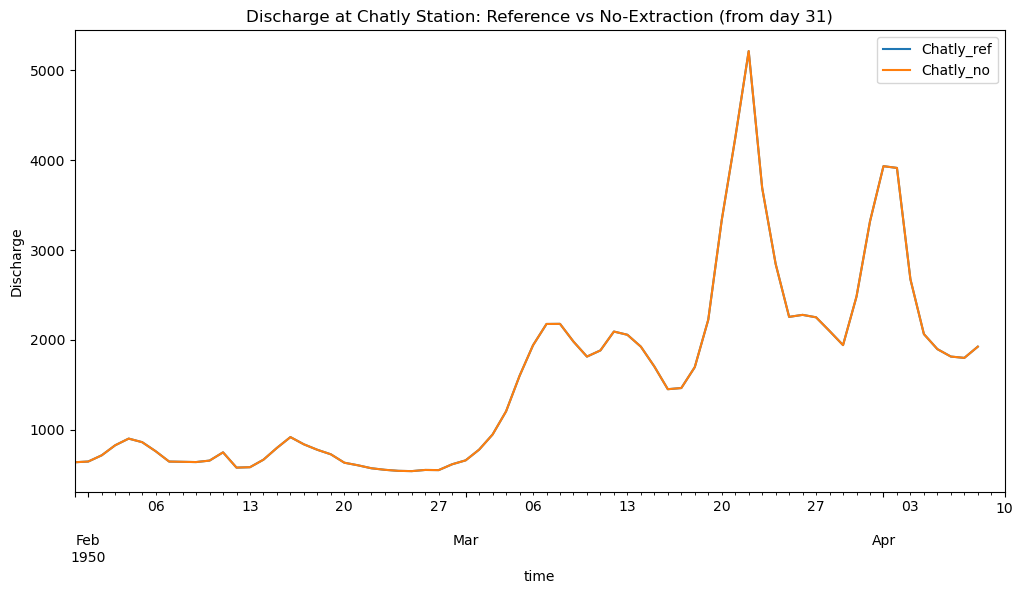

In [21]:
plot_df = Stations_timeseries.iloc[30:].copy()
plot_df.plot(figsize=(12, 6), title="Discharge at Chatly Station: Reference vs No-Extraction (from day 31)")
plt.ylabel("Discharge")
plt.show()

In [22]:
plot_df.tail()


,Chatly_ref,Chatly_no
time,,
1950-04-06 00:00:00+00:00,1813.000366,1813.000366
1950-04-07 00:00:00+00:00,1798.161987,1798.161987
1950-04-08 00:00:00+00:00,1923.280029,1923.280029
1950-04-09 00:00:00+00:00,NaN,NaN
1950-04-10 00:00:00+00:00,NaN,NaN


In [ ]:
print("="*60)
print("IRRIGATION ALLOCATION SUMMARY")
print("="*60)
print(f"\nTotal matched demands across all timesteps:")
print(f"  Min: {irrigation_diag_df['matched_demands'].min()}")
print(f"  Max: {irrigation_diag_df['matched_demands'].max()}")
print(f"  Mean: {irrigation_diag_df['matched_demands'].mean():.1f}")
print(f"  Total across all days: {irrigation_diag_df['matched_demands'].sum()}")

print(f"\nTotal extracted volume across all timesteps:")
print(f"  Min: {irrigation_diag_df['extracted_total'].min():.6g}")
print(f"  Max: {irrigation_diag_df['extracted_total'].max():.6g}")
print(f"  Mean: {irrigation_diag_df['extracted_total'].mean():.6g}")
print(f"  Total: {irrigation_diag_df['extracted_total'].sum():.6g}")

print(f"\nDemand vs Extracted:")
print(f"  Total demand: {irrigation_diag_df['total_demand'].sum():.6g}")
print(f"  Total extracted: {irrigation_diag_df['total_extracted'].sum():.6g}")
print(f"  Total unmet: {irrigation_diag_df['total_unmet'].sum():.6g}")
print(f"  Extraction ratio: {(irrigation_diag_df['total_extracted'].sum() / irrigation_diag_df['total_demand'].sum() * 100) if irrigation_diag_df['total_demand'].sum() > 0 else 0:.1f}%")

print("\nFirst 3 timesteps:")
print(irrigation_diag_df[["time", "matched_demands", "extracted_total", "total_demand", "total_extracted"]].head(3).to_string())

print("\nLast 3 timesteps:")
print(irrigation_diag_df[["time", "matched_demands", "extracted_total", "total_demand", "total_extracted"]].tail(3).to_string())

In [ ]:
# Plot irrigation allocation diagnostics
import matplotlib.pyplot as plt
import pandas as pd

if irrigation_diag_df.empty:
    print("irrigation_diag_df is empty. Run the allocation loop first.")
else:
    plot_df = irrigation_diag_df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], errors="coerce")
    plot_df = plot_df.sort_values("time")

    # Fraction of daily demand that could be extracted from channel storage
    denom = plot_df["total_demand"].replace(0, pd.NA)
    plot_df["extraction_ratio_pct"] = (plot_df["total_extracted"] / denom * 100).fillna(0.0)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # Panel 1: absolute volumes
    axes[0].plot(plot_df["time"], plot_df["total_demand"], label="total_demand", linewidth=2.0)
    axes[0].plot(plot_df["time"], plot_df["total_extracted"], label="total_extracted", linewidth=2.0)
    axes[0].plot(plot_df["time"], plot_df["total_unmet"], label="total_unmet", linewidth=1.8, alpha=0.9)
    axes[0].set_ylabel("Volume per timestep")
    axes[0].set_title("Irrigation Allocation: Demand, Extracted, and Unmet")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="upper right")

    # Panel 2: efficiency and matched demand points
    ax2 = axes[1]
    ax2.plot(plot_df["time"], plot_df["extraction_ratio_pct"], color="tab:green", label="extraction_ratio_pct", linewidth=2.0)
    ax2.set_ylabel("Extraction ratio (%)", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")
    ax2.grid(alpha=0.25)

    ax3 = ax2.twinx()
    ax3.plot(plot_df["time"], plot_df["matched_demands"], color="tab:purple", label="matched_demands", linewidth=1.8, alpha=0.85)
    ax3.set_ylabel("Matched demand cells", color="tab:purple")
    ax3.tick_params(axis="y", labelcolor="tab:purple")

    # Combined legend for panel 2
    h2, l2 = ax2.get_legend_handles_labels()
    h3, l3 = ax3.get_legend_handles_labels()
    ax2.legend(h2 + h3, l2 + l3, loc="upper right")

    axes[1].set_xlabel("time")
    plt.tight_layout()
    plt.show()

In [ ]:
# === DEBUG: Trace full allocation with test data ===

test_demand_var, test_demand_da = _get_first_available_demand_da(reference, preferred_demand_vars)
channel_storage_da = reference.get_value_as_xarray("channel_storage")

print("Testing allocation function with real data...")

# Manually replicate allocation logic with debugging
demand_df = _to_latlon_df(test_demand_da, "demand")
demand_df = demand_df[demand_df["demand"] > 0].copy()
demand_df["demand"] = demand_df["demand"] * 10  # demand_scale

print(f"1. Filtered demand: {len(demand_df)} rows")

# Spatial matching
demand_xy = demand_df[["lat", "lon"]].to_numpy(dtype=float)
mapping_xy = demand_to_channel_map_df[["lat", "lon"]].to_numpy(dtype=float)

try:
    from scipy.spatial import cKDTree
    tree = cKDTree(mapping_xy)
    _, nearest_indices = tree.query(demand_xy, k=1)
except:
    nearest_indices = _nearest_source_ids(demand_xy, mapping_xy, chunk_size=4000)

print(f"2. Matched indices: shape {nearest_indices.shape}, unique values: {np.unique(nearest_indices).shape[0]}")

# Concat with mapping
matched_mapping = demand_to_channel_map_df.iloc[nearest_indices].reset_index(drop=True)
print(f"3. Matched mapping shape: {matched_mapping.shape}, columns: {matched_mapping.columns.tolist()}")

demand_df_reset = demand_df.reset_index(drop=True)
demand_df_merged = pd.concat([demand_df_reset, matched_mapping[["source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]]], axis=1)
print(f"4. After concat: shape {demand_df_merged.shape}")
print(f"   Columns: {demand_df_merged.columns.tolist()}")
print(f"   source_id null count: {demand_df_merged['source_id'].isna().sum()}")
print(f"   source_flat_idx null count: {demand_df_merged['source_flat_idx'].isna().sum()}")

demand_df_merged[["source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"]] = demand_df_merged[[
    "source_id", "source_flat_idx", "source_lat_idx", "source_lon_idx"
]].astype(np.int64)

print(f"5. After dtype conversion: {len(demand_df_merged)} rows remain")
print(f"   First 3 rows:\n{demand_df_merged[['lat', 'lon', 'demand', 'source_id']].head(3)}")

In [ ]:
# === ANALYSIS: Understand grid mismatch ===

# What is the discharge grid (used for mapping template)?
print("Discharge grid (da):")
print(f"  Shape: {da.shape}")
print(f"  Dims: {da.dims}")
lat_dim, lon_dim = da.dims[:2]
print(f"  Lat range: {da[lat_dim].min().item():.6f} to {da[lat_dim].max().item():.6f}")
print(f"  Lon range: {da[lon_dim].min().item():.6f} to {da[lon_dim].max().item():.6f}")

# What is the demand grid (from irrigation variable)?
demand_var, demand_da = _get_first_available_demand_da(reference, preferred_demand_vars)
demand_lat_dim, demand_lon_dim = demand_da.dims[:2]
print(f"\nDemand grid ({demand_var}):")
print(f"  Shape: {demand_da.shape}")
print(f"  Dims: {demand_da.dims}")
print(f"  Lat range: {demand_da[demand_lat_dim].min().item():.6f} to {demand_da[demand_lat_dim].max().item():.6f}")
print(f"  Lon range: {demand_da[demand_lon_dim].min().item():.6f} to {demand_da[demand_lon_dim].max().item():.6f}")

print(f"\n**Grids DO NOT overlap!**")
print(f"The mapping was built from the discharge grid (Aral Sea), but demand is in a different region.")
print(f"Solution: Build mapping using the DEMAND grid as template instead of discharge grid.")

In [ ]:
# === DIAGNOSTIC: Why is extracted volume so small? ===
import numpy as np
import pandas as pd

demand_var_now, demand_da_now = _get_first_available_demand_da(reference, preferred_demand_vars)
storage_da_now = reference.get_value_as_xarray("channel_storage")

demand_df_now = _to_latlon_df(demand_da_now, "demand")
demand_df_now = demand_df_now[demand_df_now["demand"] > 0].copy()
demand_df_now["demand"] = demand_df_now["demand"] * float(demand_scale)

storage_flat_now = np.asarray(storage_da_now.values, dtype=float).reshape(-1)
source_flat_idx = channel_source_df["source_flat_idx"].to_numpy(dtype=np.int64)
source_storage_now = storage_flat_now[source_flat_idx]

total_demand_now = float(demand_df_now["demand"].sum())
total_storage_grid = float(np.nansum(np.clip(storage_flat_now, 0.0, None)))
total_storage_sources = float(np.nansum(np.clip(source_storage_now, 0.0, None)))

n_source_cells = int(len(source_storage_now))
n_source_pos = int(np.count_nonzero(np.nan_to_num(source_storage_now, nan=0.0) > 0))

print("=" * 70)
print("EXTRACTION DIAGNOSTIC")
print("=" * 70)
print(f"Demand variable: {demand_var_now}")
print(f"Demand points (>0): {len(demand_df_now)}")
print(f"Total demand (scaled): {total_demand_now:.6g}")
print()
print("Storage totals:")
print(f"  Whole grid positive storage sum: {total_storage_grid:.6g}")
print(f"  Mapped source-cell positive storage sum (hard ceiling this timestep): {total_storage_sources:.6g}")
print(f"  Fraction of whole-grid storage reachable by mapping: {(100.0 * total_storage_sources / total_storage_grid) if total_storage_grid > 0 else 0.0:.4f}%")
print()
print("Mapped source-cell stats:")
print(f"  Source cells: {n_source_cells}")
print(f"  Source cells with storage > 0: {n_source_pos}")
print(f"  Mean source storage: {float(np.nanmean(source_storage_now)):.6g}")
print(f"  Median source storage: {float(np.nanmedian(source_storage_now)):.6g}")
print(f"  Max source storage: {float(np.nanmax(source_storage_now)):.6g}")
print()
print("Interpretation:")
if total_storage_sources <= 0:
    print("  No usable storage at mapped source cells. Extraction will be ~0 regardless of total grid storage.")
elif total_storage_sources < total_demand_now * 0.01:
    print("  Reachable source storage is tiny relative to demand; very low extraction is expected.")
else:
    print("  Reachable source storage is not tiny; check units and mapping consistency.")

# Basic consistency checks for indexing/mapping assumptions.
print()
print("Consistency checks:")
print(f"  storage_da dims: {storage_da_now.dims}")
print(f"  max source_flat_idx: {int(source_flat_idx.max())}")
print(f"  storage_flat size: {int(storage_flat_now.size)}")
if int(source_flat_idx.max()) >= int(storage_flat_now.size):
    print("  WARNING: source_flat_idx exceeds storage array size -> index mapping is invalid.")
else:
    print("  source_flat_idx fits within storage array size.")

top_sources = pd.DataFrame({
    "source_id": channel_source_df["source_id"].to_numpy(dtype=np.int64),
    "source_storage": source_storage_now,
}).sort_values("source_storage", ascending=False).head(10)
print()
print("Top 10 source storages:")
display(top_sources.reset_index(drop=True))

In [ ]:
# Compact summary so Copilot can read exact values without huge rich-table output
if "irrigation_diag_df" in globals() and not irrigation_diag_df.empty:
    last = irrigation_diag_df.tail(1).iloc[0]
    ratio = (last["total_extracted"] / last["total_demand"]) if last["total_demand"] > 0 else float("nan")
    print("LAST_TIMESTEP")
    print(f"time={last['time']}")
    print(f"total_demand={last['total_demand']:.6g}")
    print(f"total_extracted={last['total_extracted']:.6g}")
    print(f"extraction_ratio={ratio:.6e}")
    print(f"matched_demands={int(last['matched_demands'])}")
    print(f"mean_storage_before={last['mean_storage_before']:.6g}")
else:
    print("irrigation_diag_df missing or empty")

if all(v in globals() for v in ["total_storage_grid", "total_storage_sources", "total_demand_now"]):
    reachable_ratio = (total_storage_sources / total_storage_grid) if total_storage_grid > 0 else float("nan")
    demand_cover = (total_storage_sources / total_demand_now) if total_demand_now > 0 else float("nan")
    print("DIAGNOSTIC")
    print(f"total_storage_grid={total_storage_grid:.6g}")
    print(f"total_storage_sources={total_storage_sources:.6g}")
    print(f"reachable_storage_fraction={reachable_ratio:.6e}")
    print(f"source_storage_vs_demand={demand_cover:.6e}")
else:
    print("diagnostic variables not found; run Cell 24 first")

In [ ]:
# Per-source diagnostic: where demand is routed vs where storage exists
import numpy as np
import pandas as pd

# Rebuild current demand->source assignment using the same logic as allocator.
demand_var_diag, demand_da_diag = _get_first_available_demand_da(reference, preferred_demand_vars)
storage_da_diag = reference.get_value_as_xarray("channel_storage")

demand_df_diag = _to_latlon_df(demand_da_diag, "demand")
demand_df_diag = demand_df_diag[demand_df_diag["demand"] > 0].copy()
demand_df_diag["demand"] = demand_df_diag["demand"] * float(demand_scale)

demand_xy = demand_df_diag[["lat", "lon"]].to_numpy(dtype=float)
mapping_xy = demand_to_channel_map_df[["lat", "lon"]].to_numpy(dtype=float)

try:
    from scipy.spatial import cKDTree  # type: ignore
    tree = cKDTree(mapping_xy)
    _, nearest_indices = tree.query(demand_xy, k=1)
except Exception:
    nearest_indices = _nearest_source_ids(demand_xy, mapping_xy, chunk_size=4000)

matched_mapping = demand_to_channel_map_df.iloc[nearest_indices].reset_index(drop=True)
demand_df_diag = pd.concat(
    [demand_df_diag.reset_index(drop=True), matched_mapping[["source_id", "source_flat_idx"]]],
    axis=1,
)
demand_df_diag[["source_id", "source_flat_idx"]] = demand_df_diag[["source_id", "source_flat_idx"]].astype(np.int64)

# Current storage at source IDs.
storage_flat = np.asarray(storage_da_diag.values, dtype=float).reshape(-1)
source_state = channel_source_df[["source_id", "source_flat_idx"]].drop_duplicates().copy()
source_state["source_flat_idx"] = source_state["source_flat_idx"].astype(np.int64)
source_state["source_storage"] = storage_flat[source_state["source_flat_idx"].to_numpy(dtype=np.int64)]

# Demand aggregated per source.
demand_by_source = demand_df_diag.groupby("source_id", as_index=False).agg(
    demand_points=("demand", "size"),
    source_demand=("demand", "sum"),
)

# Join and compute theoretical per-source extraction cap.
source_diag = source_state.merge(demand_by_source, on="source_id", how="left")
source_diag[["demand_points", "source_demand"]] = source_diag[["demand_points", "source_demand"]].fillna(0.0)
source_diag["demand_points"] = source_diag["demand_points"].astype(int)
source_diag["usable_storage"] = np.clip(source_diag["source_storage"], 0.0, None)
source_diag["theoretical_extract"] = np.minimum(source_diag["usable_storage"], source_diag["source_demand"] + 0.0)

tot_demand = float(source_diag["source_demand"].sum())
tot_usable = float(source_diag["usable_storage"].sum())
tot_theoretical = float(source_diag["theoretical_extract"].sum())
active_sources = int((source_diag["demand_points"] > 0).sum())
active_zero_storage = int(((source_diag["demand_points"] > 0) & (source_diag["usable_storage"] <= 0)).sum())

print("=" * 72)
print("PER-SOURCE ROUTING DIAGNOSTIC")
print("=" * 72)
print(f"Demand variable: {demand_var_diag}")
print(f"Total demand points: {len(demand_df_diag)}")
print(f"Active source IDs receiving demand: {active_sources}")
print(f"Active source IDs with zero/non-positive storage: {active_zero_storage}")
print(f"Total demand assigned to sources: {tot_demand:.6g}")
print(f"Total usable source storage: {tot_usable:.6g}")
print(f"Theoretical max extract (per-source cap): {tot_theoretical:.6g}")
print(f"Theoretical extraction ratio: {(tot_theoretical / tot_demand) if tot_demand > 0 else np.nan:.6e}")

print()
print("Top 15 by assigned demand:")
display(
    source_diag.sort_values("source_demand", ascending=False)[
        ["source_id", "demand_points", "source_demand", "usable_storage", "theoretical_extract"]
    ].head(15).reset_index(drop=True)
)

print()
print("Top 15 by usable storage:")
display(
    source_diag.sort_values("usable_storage", ascending=False)[
        ["source_id", "demand_points", "source_demand", "usable_storage", "theoretical_extract"]
    ].head(15).reset_index(drop=True)
)

print()
print("15 active-demand sources with least usable storage:")
display(
    source_diag[source_diag["demand_points"] > 0]
    .sort_values("usable_storage", ascending=True)[
        ["source_id", "demand_points", "source_demand", "usable_storage", "theoretical_extract"]
    ].head(15).reset_index(drop=True)
)